To create a labelled dataset we have to collect all the label folders under one folder. You can do this with commands.

In [2]:
# create one folder to collect label image folders
!mkdir lung_colon_folder

print("---Copying files under the folder---")
# copy files
!cp -R /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets/* lung_colon_folder
!cp -R /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/* lung_colon_folder
print("---Done copying---")

mkdir: cannot create directory ‘lung_colon_folder’: File exists
---Copying files under the folder---
---Done copying---


In [3]:
!pip install tensorflow==2.11.0 -i https://pypi.org/simple
!pip install transformers datasets tensorboard -i https://pypi.org/simple


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.3/588.3 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 81.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 75.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 96.0 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.2/439.2 kB 41.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.1 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 62.6 MB/s eta 0:00:00
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.12.0
    Uninstalling tensorflow-estimator-2.12.0:
      Successfully uninstalled tensorflow-estimator-2.12.0
  Attempting uninstall: tensorboard-data-server
    Found existing installation: tensorboard-data-server 0.7.0
    Uninstalling tensorboard-data-server-0.7.0:
      Successfully uninstalled tensorboard-data-s

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import random

import time
import os

import datasets
from transformers import ViTFeatureExtractor
from tensorflow import keras
from tensorflow.keras import layers

from glob import glob

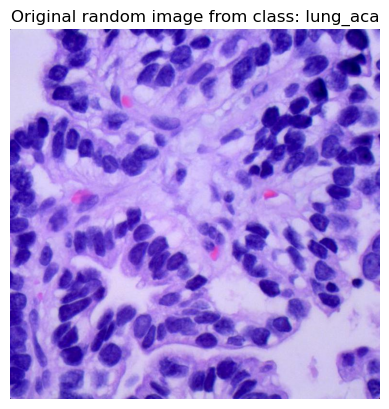

In [5]:
target_class = random.choice(os.listdir("lung_colon_folder/")) # choose a random class
target_dir = "lung_colon_folder/" + target_class # create the target directory
random_image = random.choice(os.listdir(target_dir)) # choose a random image from target directory
random_image_path = target_dir + "/" + random_image # create the choosen random image path
img = mpimg.imread(random_image_path) # read in the chosen target image
plt.imshow(img) # plot the target image
plt.title(f"Original random image from class: {target_class}")
plt.axis(False); # turn off the axes

In [6]:
def create_image_folder_dataset(root_path):
    """creates `Dataset` from image folder structure"""

    # get class names by folders names
    _CLASS_NAMES= os.listdir(root_path)
    # defines `datasets` features`
    features=datasets.Features({
                      "img": datasets.Image(),
                      "label": datasets.features.ClassLabel(names=_CLASS_NAMES),
                  })
    # temp list holding datapoints for creation
    img_data_files=[]
    label_data_files=[]
    # load images into list for creation
    for img_class in os.listdir(root_path):
        for img in os.listdir(os.path.join(root_path,img_class))[:10]:
            path_=os.path.join(root_path,img_class,img)
            img_data_files.append(path_)
            label_data_files.append(img_class)
    # create dataset
    ds = datasets.Dataset.from_dict({"img":img_data_files,"label":label_data_files},features=features)
    return ds

In [ ]:
#!rm -rf lung_colon_image_set/.DS_Store
#!rm -rf lung_colon_image_set/colon_aca/.DS_Store

In [7]:
cancer_ds = create_image_folder_dataset("lung_colon_folder")

In [8]:
cancer_ds

Dataset({
    features: ['img', 'label'],
    num_rows: 50
})

Get class names from Dataset instance.

In [9]:
class_labels = cancer_ds.features["label"].names

In [14]:
from transformers import ViTImageProcessor

model_name = "google/vit-base-patch16-224-in21k"
feature_extractor = ViTImageProcessor.from_pretrained(model_name)


In [16]:
def process(images):
    images.update(feature_extractor(images["img"], ))
    return images

In [17]:
cancer_ds = cancer_ds.rename_column("label", "labels")

In [22]:
!pip install --upgrade jupyterlab_widgets ipywidgets

processed_dataset = cancer_ds.map(process, batched=True)



  0%|          | 0/1 [00:00<?, ?ba/s]

In [25]:
test_size = 0.15

# Apply train_test_split() to the 'train' dataset
processed_dataset = processed_dataset["train"].train_test_split(test_size=test_size)

# Print dataset structure
print(processed_dataset)


DatasetDict({
    train: Dataset({
        features: ['img', 'labels', 'pixel_values'],
        num_rows: 35
    })
    test: Dataset({
        features: ['img', 'labels', 'pixel_values'],
        num_rows: 7
    })
})


In [27]:
from huggingface_hub import HfFolder
import tensorflow as tf

id2label = {str(i): label for i, label in enumerate(class_labels)}
label2id = {v: k for k, v in id2label.items()}

num_train_epochs = 1
train_batch_size = 32
eval_batch_size = 32
learning_rate = 3e-5
weight_decay_rate=0.01
num_warmup_steps=0
output_dir=model_name.split("/")[1]
hub_token = HfFolder.get_token() # or your token directly "hf_xxx"
hub_model_id = f'{model_name.split("/")[1]}-lung_and_colon' # this is your model name in huggingface, create first
fp16=False # set to True if you have a GPU

# Train in mixed-precision float16
# Comment this line out if you're using a GPU that will not benefit from this
if fp16:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")

Here we're converting to `tf.Dataset`.



In [29]:
from transformers import DefaultDataCollator

# Data collator that will dynamically pad the inputs received, as well as the labels.
data_collator = DefaultDataCollator(return_tensors="tf")

# converting our train dataset to tf.data.Dataset
tf_train_dataset = processed_dataset["train"].to_tf_dataset(
   columns=['pixel_values'],
   label_cols=["labels"],
   shuffle=True,
   batch_size=train_batch_size,
   collate_fn=data_collator)

# converting our test dataset to tf.data.Dataset
tf_eval_dataset = processed_dataset["test"].to_tf_dataset(
   columns=['pixel_values'],
   label_cols=["labels"],
   shuffle=True,
   batch_size=eval_batch_size,
   collate_fn=data_collator)

Downloading pre-trained model with `TFViTForImageClassification` class.

## What is top-3-accuracy?

Top-3 accuracy is an evaluation metric commonly used in multi-class classification tasks. It measures the percentage of predictions where the correct label appears in the top three predicted classes.

To calculate the top-3 accuracy, the model's predicted probabilities for each class are ranked, and the top three classes with the highest probabilities are considered. If the true label (the ground truth) is among these top three predictions, it is counted as a correct prediction.

Top-3 accuracy is a more forgiving metric than traditional accuracy because it allows for some flexibility in predicting the correct class. It accounts for cases where the model might have made a mistake in assigning the highest probability to the true class but still predicted some of the other relevant classes.

This metric is particularly useful in scenarios where the order of importance or relevance among the predicted classes is not well-defined, or when there are multiple valid correct answers for a given input. By considering the top three predictions, it provides a more lenient evaluation measure that reflects a broader understanding of the model's performance.

In [38]:
from transformers import TFViTForImageClassification, create_optimizer
import tensorflow as tf

# Ensure train & validation datasets are loaded
if "tf_train_dataset" not in locals():
    raise ValueError("Training dataset (tf_train_dataset) is not defined!")
if "tf_val_dataset" not in locals():
    print("Warning: Validation dataset (tf_val_dataset) is missing. Using training data for validation.")
    tf_val_dataset = tf_train_dataset  # Use training set as fallback

# Hyperparameters
learning_rate = 2e-5
num_train_epochs = 20
weight_decay_rate = 0.01
num_warmup_steps = 0
model_name = "google/vit-base-patch16-224-in21k"

# Compute training steps
num_train_steps = len(tf_train_dataset) * num_train_epochs

# Create optimizer with weight decay
optimizer, lr_schedule = create_optimizer(
    init_lr=learning_rate,
    num_train_steps=num_train_steps,
    weight_decay_rate=weight_decay_rate,
    num_warmup_steps=num_warmup_steps,
)

# Load pre-trained ViT model
model = TFViTForImageClassification.from_pretrained(
    model_name,
    from_pt=False,  # Ensures TensorFlow weights are used, not PyTorch
    num_labels=len(class_labels),
    id2label=id2label,
    label2id=label2id,
)

# Define loss function
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Define evaluation metrics
metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(3, name="top-3-accuracy"),
]

# Compile model
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Train the model
history = model.fit(
    tf_train_dataset,
    validation_data=tf_val_dataset,  # Ensures dataset is available
    epochs=num_train_epochs
)

# Save the fine-tuned model
model.save_pretrained("fine_tuned_vit")

print("Model fine-tuning complete and saved.")


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTForImageClassification: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing TFViTForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTForImageClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFViTForImageClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20
1/1 [==============================] - 13s 13s/step - loss: 1.5813 - accuracy: 0.3438 - top-3-accuracy: 0.7812 - val_loss: 1.5208 - val_accuracy: 0.6250 - val_top-3-accuracy: 0.8750
Epoch 2/20
1/1 [==============================] - 3s 3s/step - loss: 1.5287 - accuracy: 0.5625 - top-3-accuracy: 0.8750 - val_loss: 1.4658 - val_accuracy: 0.7500 - val_top-3-accuracy: 0.9688
Epoch 3/20
1/1 [==============================] - 3s 3s/step - loss: 1.4668 - accuracy: 0.7188 - top-3-accuracy: 1.0000 - val_loss: 1.4163 - val_accuracy: 0.8125 - val_top-3-accuracy: 0.9688
Epoch 4/20
1/1 [==============================] - 3s 3s/step - loss: 1.4190 - accuracy: 0.8438 - top-3-accuracy: 0.9688 - val_loss: 1.3743 - val_accuracy: 0.9688 - val_top-3-accuracy: 1.0000
Epoch 5/20
1/1 [==============================] - 3s 3s/step - loss: 1.3738 - accuracy: 0.9688 - top-3-accuracy: 1.0000 - val_loss: 1.3379 - val_accuracy: 0.9688 - val_top-3-accuracy: 1.0000
Epoch 6/20
1/1 [===========================

We will push the Tensorboard logs alongside the weights to the Hub, enabling us to utilize the "Training Metrics" feature for real-time monitoring of our training performance. We're adding some callbacks like EarlyStopping. The training process will monitor the "val_accuracy" metric and terminate the training when it fails to show any improvement beyond a certain patience value, which is 1 for this case. So, since we're finetuning a model we're likely get good results, 1 is the ideal patience.

But since I'm gonna pass this part you should  run the below cell.

In [ ]:
#import os
#from transformers.keras_callbacks import PushToHubCallback
#from tensorflow.keras.callbacks import TensorBoard as TensorboardCallback, EarlyStopping

#callbacks=[]

#callbacks.append(TensorboardCallback(log_dir=os.path.join(output_dir,"logs")))
#callbacks.append(EarlyStopping(monitor="val_accuracy",patience=1))
#if hub_token:
#    callbacks.append(PushToHubCallback(output_dir=output_dir,
#                                     hub_model_id=hub_model_id,
#                                     hub_token=hub_token))

In [39]:
train_results = model.fit(
    tf_train_dataset,
    validation_data=tf_eval_dataset,
    #callbacks=callbacks,
    epochs=num_train_epochs,
)

Epoch 1/20
1/1 [==============================] - 2s 2s/step - loss: 1.0711 - accuracy: 1.0000 - top-3-accuracy: 1.0000
Epoch 2/20
1/1 [==============================] - 2s 2s/step - loss: 1.0599 - accuracy: 1.0000 - top-3-accuracy: 1.0000
Epoch 3/20
1/1 [==============================] - 2s 2s/step - loss: 1.0773 - accuracy: 1.0000 - top-3-accuracy: 1.0000
Epoch 4/20
1/1 [==============================] - 2s 2s/step - loss: 1.0715 - accuracy: 1.0000 - top-3-accuracy: 1.0000
Epoch 5/20
1/1 [==============================] - 2s 2s/step - loss: 1.0616 - accuracy: 1.0000 - top-3-accuracy: 1.0000
Epoch 6/20
1/1 [==============================] - 2s 2s/step - loss: 1.0667 - accuracy: 1.0000 - top-3-accuracy: 1.0000
Epoch 7/20
1/1 [==============================] - 2s 2s/step - loss: 1.0636 - accuracy: 1.0000 - top-3-accuracy: 1.0000
Epoch 8/20
1/1 [==============================] - 2s 2s/step - loss: 1.0550 - accuracy: 1.0000 - top-3-accuracy: 1.0000
Epoch 9/20
1/1 [========================

In [ ]:
#feature_extractor.save_pretrained(output_dir)